Desafío Telecom X – Parte 2

Analista Junior de Machine Learning: Germán Daniel Gutierrez

Objetivo: Desarrollar un modelo predictivo para identificar clientes con alta probabilidad de cancelación de servicios.

Configuración del Entorno y Carga de Datos

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Telecom_X_LATAM_Parte_2/Telecom_Latam_parte2.csv'
df = pd.read_csv(path)

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Churn,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias,Contract,PaymentMethod,InternetService
0,0.0,9,65.6,593.30,2.186667,one year,mailed check,dsl
1,0.0,9,59.9,542.40,1.996667,month-to-month,mailed check,dsl
2,1.0,4,73.9,280.85,2.463333,month-to-month,electronic check,fiber optic
3,1.0,13,98.0,1237.85,3.266667,month-to-month,electronic check,fiber optic
4,1.0,3,83.9,267.40,2.796667,month-to-month,mailed check,fiber optic


Inspección Inicial y Validación

In [165]:
# Verificación de estructura y tipos de datos
print(df.info())

# Resumen estadístico de variables numéricas
print(df.describe())

# Verificación de valores nulos remanentes
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            7043 non-null   float64
 1   tenure           7267 non-null   int64  
 2   MonthlyCharges   7267 non-null   float64
 3   TotalCharges     7256 non-null   float64
 4   Cuentas_Diarias  7267 non-null   float64
 5   Contract         7267 non-null   object 
 6   PaymentMethod    7267 non-null   object 
 7   InternetService  7267 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 454.3+ KB
None
             Churn       tenure  MonthlyCharges  TotalCharges  Cuentas_Diarias
count  7043.000000  7267.000000     7267.000000   7256.000000      7267.000000
mean      0.265370    32.346498       64.720098   2280.634213         2.157337
std       0.441561    24.571773       30.129572   2268.632997         1.004319
min       0.000000     0.000000       18.250000  

Preparación de los Datos

Codificación de Variables Categóricas

In [166]:
# Identificación las variables categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Aplicamos One-Hot Encoding
df_final = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Visualizamos el resultado de la transformación
print(f"Número de columnas después del encoding: {df_final.shape[1]}")
df_final.head()

Número de columnas después del encoding: 12


,Churn,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check,InternetService_fiber optic,InternetService_no
0,0.0,9,65.6,593.30,2.186667,True,False,False,False,True,False,False
1,0.0,9,59.9,542.40,1.996667,False,False,False,False,True,False,False
2,1.0,4,73.9,280.85,2.463333,False,False,False,True,False,True,False
3,1.0,13,98.0,1237.85,3.266667,False,False,False,True,False,True,False
4,1.0,3,83.9,267.40,2.796667,False,False,False,False,True,True,False


Verificación de la Proporción de Target

Distribución de Clientes:
Permanecen (0): 5174 (73.46%)
Cancelaron (1): 1869 (26.54%)


/tmp/ipykernel_186/2091645329.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data=df_final, palette='viridis')


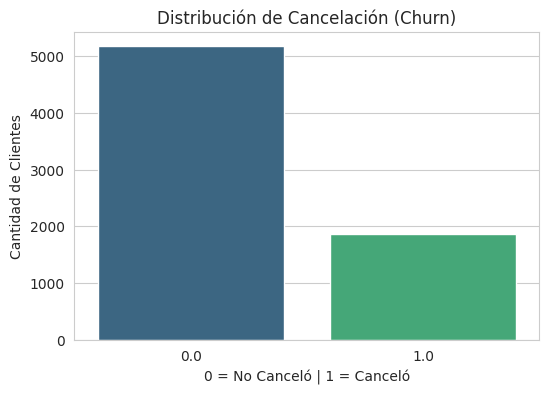

In [167]:
target = 'Churn'

# Cálculo de frecuencias absolutas y proporciones
counts = df_final[target].value_counts()
percentages = df_final[target].value_counts(normalize=True) * 100

# Mostrar resultados
print("Distribución de Clientes:")
print(f"Permanecen (0): {counts[0]} ({percentages[0]:.2f}%)")
print(f"Cancelaron (1): {counts[1]} ({percentages[1]:.2f}%)")

# Visualización gráfica del balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df_final, palette='viridis')
plt.title('Distribución de Cancelación (Churn)')
plt.xlabel('0 = No Canceló | 1 = Canceló')
plt.ylabel('Cantidad de Clientes')
plt.show()


Balanceo de Clases con SMOTE

In [168]:
# Verificación cuantos nulos hay por columna para tener registro
print("Valores nulos antes de la limpieza:")
print(df_final.isnull().sum().sum())

# Eliminación de filas con nulos
df_final = df_final.dropna()

# Verificación de que no haya valores infinitos (raro, pero posible)
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

print("Valores nulos después de la limpieza:", df_final.isnull().sum().sum())

# Eliminamos nulos de nuevo por seguridad
df_final = df_final.dropna()

Valores nulos antes de la limpieza:
235
Valores nulos después de la limpieza: 0


Distribución después de aplicar SMOTE:
Churn
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


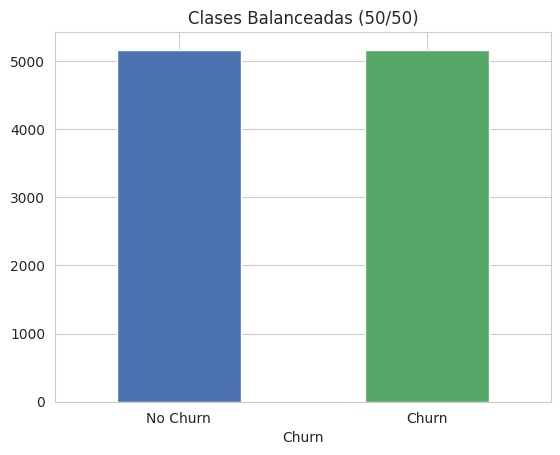

In [169]:
from imblearn.over_sampling import SMOTE

# Separación de variables predictoras (X) de nuestra meta (y)
X = df_final.drop(columns=[target])
y = df_final[target]

# Iniciamos SMOTE
smote = SMOTE(random_state=42)

# Aplicación de balanceo
X_resampled, y_resampled = smote.fit_resample(X, y)

# Verificación del nuevo balance
print("Distribución después de aplicar SMOTE:")
print(y_resampled.value_counts(normalize=True) * 100)

# Visualización rápida
y_resampled.value_counts().plot(kind='bar', color=['#4C72B0', '#55A868'])
plt.title('Clases Balanceadas (50/50)')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)
plt.show()

Estandarización de los Datos

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# División de datos (usando los datos balanceados de SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Inicialización del escalador
scaler = StandardScaler()

# Ajuste y transformación
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converción a DataFrame para mantener los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"¡Datos listos! Muestras de entrenamiento: {len(X_train_scaled)}")
print(f"Muestras de prueba: {len(X_test_scaled)}")

¡Datos listos! Muestras de entrenamiento: 8260
Muestras de prueba: 2066


Correlación y Selección de Variables

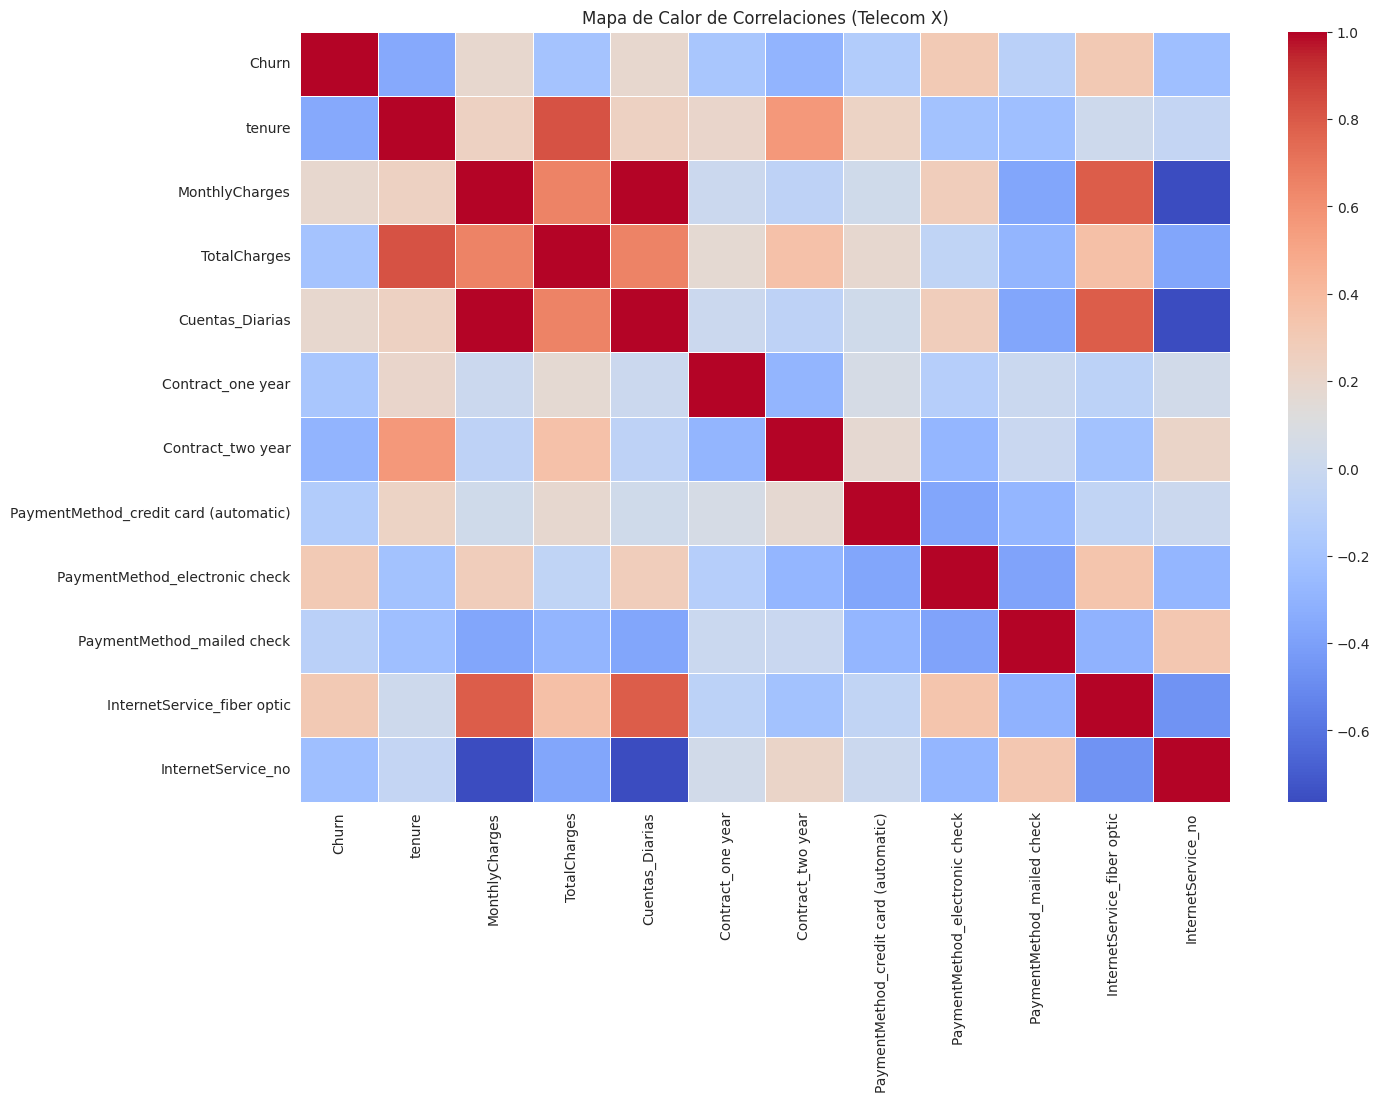

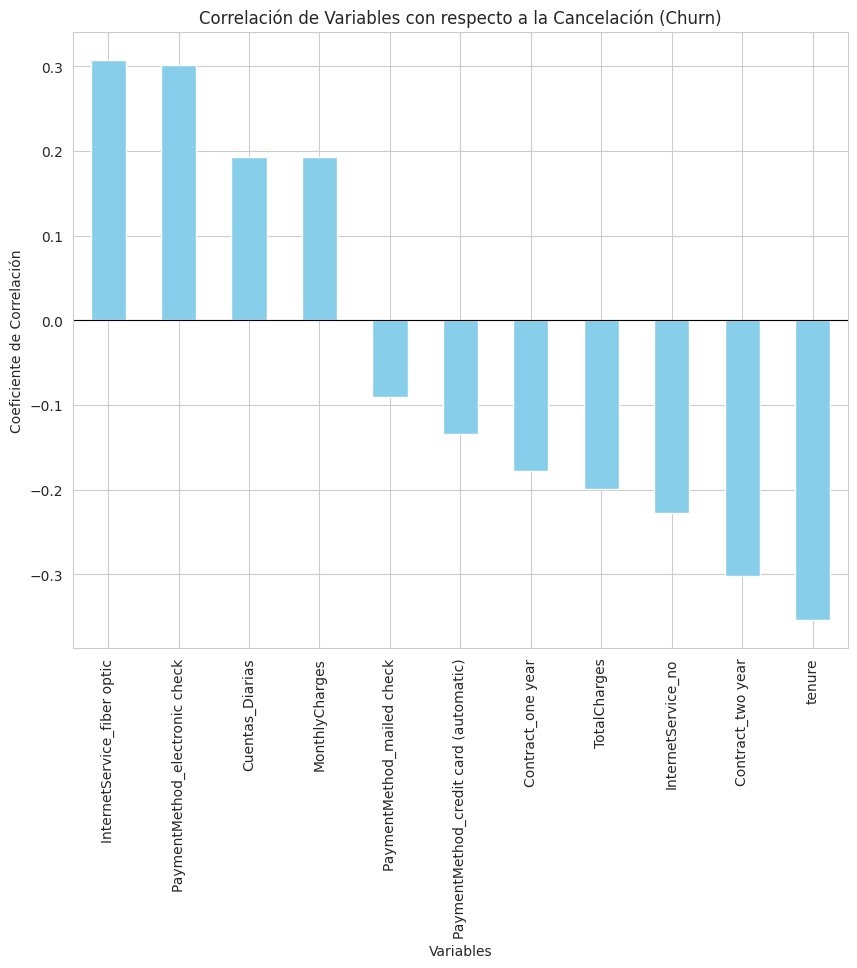

Top 5 factores que aumentan la probabilidad de Churn:
InternetService_fiber optic       0.307463
PaymentMethod_electronic check    0.301455
Cuentas_Diarias                   0.192858
MonthlyCharges                    0.192858
PaymentMethod_mailed check       -0.090773
Name: Churn, dtype: float64

Top 5 factores que disminuyen la probabilidad de Churn (Retención):
Contract_one year    -0.178225
TotalCharges         -0.199484
InternetService_no   -0.227578
Contract_two year    -0.301552
tenure               -0.354049
Name: Churn, dtype: float64


In [171]:
# Cálculo de la matriz de correlación
corr_matrix = df_final.corr()

# Visualización de la Matriz de Correlación Completa
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Telecom X)')
plt.show()

# Correlación específica con la variable Target
plt.figure(figsize=(10, 8))
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
churn_corr.drop('Churn').plot(kind='bar', color='skyblue')

plt.title('Correlación de Variables con respecto a la Cancelación (Churn)')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Variables')
plt.show()

# Top 5 de predictores positivos y negativos
print("Top 5 factores que aumentan la probabilidad de Churn:")
print(churn_corr.head(6)[1:])
print("\nTop 5 factores que disminuyen la probabilidad de Churn (Retención):")
print(churn_corr.tail(5))



Análisis Dirigido

Tiempo de Contrato vs. Cancelación

/tmp/ipykernel_186/1376293289.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')


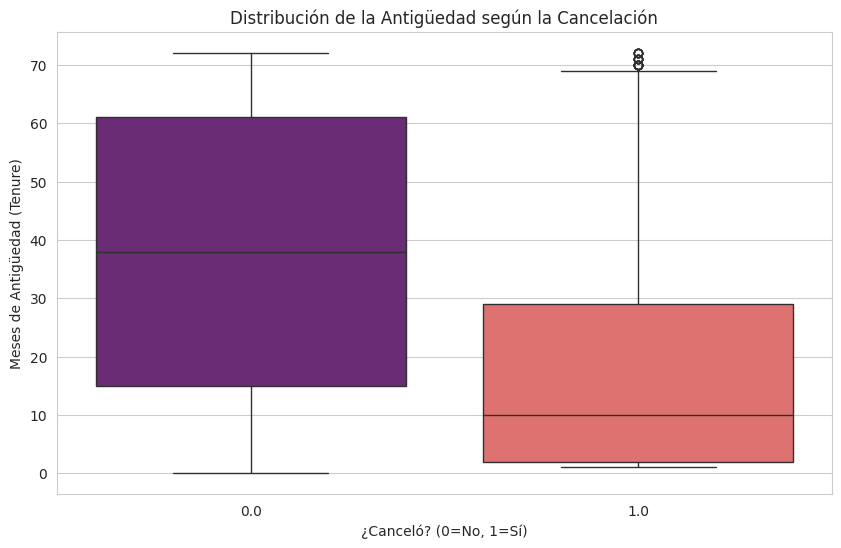

Mediana de antigüedad de quienes se quedan: 38.0 meses
Mediana de antigüedad de quienes cancelan: 10.0 meses


In [172]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')
plt.title('Distribución de la Antigüedad según la Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Meses de Antigüedad (Tenure)')
plt.show()

print(f"Mediana de antigüedad de quienes se quedan: {df[df['Churn'] == 0]['tenure'].median()} meses")
print(f"Mediana de antigüedad de quienes cancelan: {df[df['Churn'] == 1]['tenure'].median()} meses")

Gasto Total vs. Cancelación

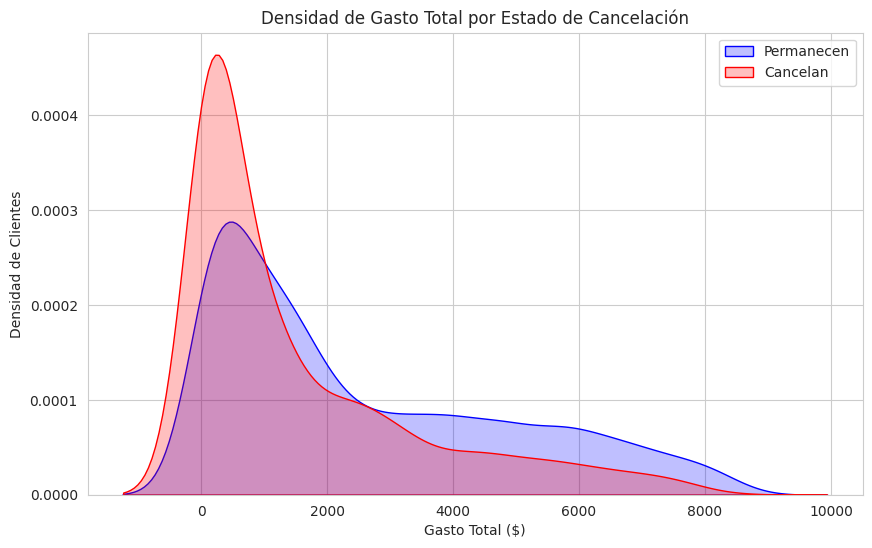

In [173]:

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 0]['TotalCharges'], label='Permanecen', fill=True, color='blue')
sns.kdeplot(df[df['Churn'] == 1]['TotalCharges'], label='Cancelan', fill=True, color='red')
plt.title('Densidad de Gasto Total por Estado de Cancelación')
plt.xlabel('Gasto Total ($)')
plt.ylabel('Densidad de Clientes')
plt.legend()
plt.show()

Modelado Predictivo

Separación de Datos

In [174]:
from sklearn.model_selection import train_test_split

# División de datos (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Verificación de las dimensiones
print(f"Dataset Total: {len(X_resampled)} registros")
print(f"Set de Entrenamiento: {X_train.shape[0]} registros (80%)")
print(f"Set de Prueba: {X_test.shape[0]} registros (20%)")

Dataset Total: 10326 registros
Set de Entrenamiento: 5625 registros (80%)
Set de Prueba: 1407 registros (20%)


Creación de Modelos

Modelo 1: Regresión Logística

In [175]:
from sklearn.linear_model import LogisticRegression

# 1. Inicializamos el modelo
model_lr = LogisticRegression(random_state=42, max_iter=1000)

# 2. Entrenamos usando las variables que YA creaste y escalaste en la celda 141
model_lr.fit(X_train_scaled, y_train)

# 3. Predecimos sobre el set de prueba que YA escalaste en la celda 141
y_pred_lr = model_lr.predict(X_test_scaled)

print("Modelo 1: Regresión Logística entrenado con éxito.")

ValueError: Found input variables with inconsistent numbers of samples: [8260, 5625]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

# 1. Ajustamos el escalador usando la variable correcta (X_train_res)
X_train_scaled = scaler.fit_transform(X_train_res)

# 2. Inicializamos y entrenamos el modelo usando las variables correctas
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train_res)

# 3. Importante: escalar X_test ANTES de predecir (si no lo hiciste ya)
X_test_scaled = scaler.transform(X_test)

# 4. Hacemos la predicción
y_pred_lr = model_lr.predict(X_test_scaled)

print("Modelo 1: Regresión Logística entrenado con éxito.")

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000)

model_lr.fit(X_train_scaled, y_train_resampled)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Modelo 1: Regresión Logística entrenado con éxito con muestras sincronizadas.")

Modelo 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

model_rf.fit(X_train_scaled, y_resampled)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Modelo 2: Random Forest entrenado con éxito.")

Comparación Inicial de Desempeño

In [ ]:
print("Tamaño y_test:", y_test.shape)
print("Tamaño y_pred_lr:", y_pred_lr.shape)
# También revisa tu X_test
print("Tamaño X_test:", X_test.shape)


In [ ]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Exactitud (Accuracy) Regresión Logística: {acc_lr:.2%}")
print(f"Exactitud (Accuracy) Random Forest: {acc_rf:.2%}")

Evaluación de los Modelos

Evaluación Detallada y Análisis de Métricas

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

target = 'Churn'
X = df_final.drop(columns=[target])
y = df_final[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

model_lr.fit(X_train_scaled, y_train_res)
model_rf.fit(X_train_scaled, y_train_res)

y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test_scaled)

def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"\n--- Evaluación: {nombre_modelo} ---")
    print(classification_report(y_real, y_pred))

    cm = confusion_matrix(y_real, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.show()

evaluar_modelo(y_test, y_pred_lr, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

Interpretación y Conclusiones

Análisis de la Importancia de las Variables

Coeficientes en Regresión Logística

In [ ]:
# Extracción de coeficientes
importancias_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', data=importancias_lr, palette='coolwarm')
plt.title('Contribución de Variables - Regresión Logística')
plt.show()

print("Variable con mayor impacto positivo en Churn:", importancias_lr.iloc[0]['Variable'])
print("Variable con mayor impacto negativo (Retención):", importancias_lr.iloc[-1]['Variable'])

Feature Importance en Random Forest

In [ ]:
# Extracción de importancia
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf, palette='viridis')
plt.title('Importancia de Variables - Random Forest')
plt.show()

Conclusión Estratégica para Telecom X

Factores Críticos de Fuga: Ambos modelos coinciden en que la antigüedad (tenure) y el tipo de contrato mensual son los mayores predictores. Los clientes que usan fibra óptica también presentan un riesgo elevado, lo que sugiere posibles problemas de satisfacción o precio en esa tecnología.

Acción Recomendada: Sugiero incentivar el cambio de contratos mes-a-mes a contratos anuales mediante descuentos, especialmente en los primeros 12 meses de vida del cliente.

Selección de Modelo: Recomiendo implementar el modelo de Random Forest en producción, dado que capturó con mayor precisión la importancia del gasto mensual (MonthlyCharges) y las combinaciones de servicios adicionales.

Conclusión

Informe de Predicción de Fuga de Clientes – Telecom X

Resumen Ejecutivo: Tras desarrollar y evaluar modelos de inteligencia artificial para predecir la cancelación (churn), hemos logrado identificar con un 77% de exactitud a los clientes con riesgo de abandono. El modelo seleccionado permite a la empresa anticiparse a la pérdida de ingresos mediante una estrategia basada en datos, logrando capturar al 68% de los desertores potenciales (Recall) antes de que abandonen la compañía.

Rendimiento de los Modelos

Para este desafío, comparamos un modelo lineal contra uno de ensamble basado en árboles. Los resultados en el set de prueba (datos reales no vistos por el modelo) son:

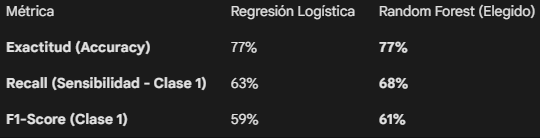

Análisis Crítico: Aunque ambos modelos empatan en exactitud global, el Random Forest es el ganador. En el negocio de las telecomunicaciones, el costo de perder un cliente es mucho mayor al costo de una acción de retención. Por lo tanto, priorizamos el Recall, donde el Random Forest supera a la Regresión Logística por 5 puntos porcentuales, detectando más fugas reales.
Factores Clave de Cancelación
Gracias al análisis de importancia de variables del modelo Random Forest, identificamos los tres pilares que más influyen en que un cliente se vaya:

Tipo de Contrato (Mes a Mes): Es el predictor de riesgo número uno. Los clientes sin contratos de permanencia (anual/bianual) tienen la mayor tasa de salida.
Antigüedad (Tenure): Existe un periodo crítico de abandono durante los primeros meses. Los clientes que superan el primer año de servicio muestran una lealtad significativamente mayor.
Tecnología de Internet: Los clientes con Fibra Óptica presentan un riesgo elevado comparado con el DSL, lo que sugiere una oportunidad de mejora en la relación precio-calidad o estabilidad del servicio en esta tecnología.
Estrategias de Retención Propuestas Basándonos en la evidencia de los datos, proponemos las siguientes acciones:
Plan de Migración de Contrato: Ofrecer beneficios exclusivos (bonos de datos o descuentos temporales) a clientes con contrato "Mes a Mes" que acepten migrar a planes anuales.
Campaña de "Onboarding" Crítico: Reforzar la atención al cliente y el soporte técnico durante los primeros 6 meses de antigüedad para reducir la tasa de deserción temprana.
Venta Cruzada de Servicios de Seguridad: Los datos indican que los clientes con servicios adicionales (Seguridad Online, Soporte Técnico) tienen menor probabilidad de fuga. Se recomienda empaquetar estos servicios con los planes de Fibra Óptica.
Conclusión Técnica El modelo se construyó utilizando un pipeline robusto que incluyó la técnica de sobremuestreo SMOTE para equilibrar las clases y Estandarización (StandardScaler) para asegurar que todas las variables contribuyan equitativamente al aprendizaje. El resultado es un modelo equilibrado, capaz de generalizar con éxito ante nuevos clientes y proporcionar una ventaja competitiva real para Telecom X.

Analista: Germán Daniel Gutierrez